# Entrenamiento y Evaluación de la Red MS-CLSTM (Proto)

Carga la arquitectura de red y la entrena con los pipelines optimizados de TensorFlow.

In [1]:
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Layer
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from scipy import stats

# Función puramente robusta para buscar y cargar el archivo .env
def load_env_variables():
    import os
    from pathlib import Path
    
    # 1. Buscar .env subiendo niveles desde el CWD actual
    try:
        start_dir = Path(os.getcwd())
    except:
        start_dir = Path(".")
        
    env_path = None
    for path in [start_dir] + list(start_dir.parents):
        temp_path = path / ".env"
        if temp_path.exists():
            env_path = temp_path
            break
            
    if env_path is None:
        raise FileNotFoundError("⚠️ No se pudo encontrar el archivo .env en la raíz del proyecto.")
        
    # 2. Leer e inyectar variables en os.environ
    with open(env_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            if "=" not in line:
                continue
            key, val = line.split("=", 1)
            os.environ[key.strip()] = val.strip()
            
    print(f"✅ Archivo .env cargado con éxito desde: {env_path}")

load_env_variables()

base_path = os.environ["PROCESSED_TENSOR_PROTO"]
models_dir = os.environ["MODELS_DL_PROTO"]

2026-05-24 23:29:50.050955: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-24 23:29:50.086493: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-24 23:29:50.963574: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


✅ Archivo .env cargado con éxito desde: /home/cbe/Proyectos/MyoTensor_Tesis/.env


In [2]:
@tf.keras.utils.register_keras_serializable()
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)
    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="normal", trainable=True)
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros", trainable=True)
        super(AttentionLayer, self).build(input_shape)
    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1)
    def get_config(self): 
        return super(AttentionLayer, self).get_config()

In [3]:
print("📖 Cargando tensores...")
X_train = np.load(f'{base_path}/X_train.npy')
y_train = np.load(f'{base_path}/y_train.npy')
X_test  = np.load(f'{base_path}/X_test.npy')
y_test  = np.load(f'{base_path}/y_test.npy')

print(f"✅ X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")

📖 Cargando tensores...
✅ X_train shape: (1638, 300, 1) | X_test shape: (410, 300, 1)


In [4]:
y_train_labels = np.argmax(y_train, axis=1)
classes = np.unique(y_train_labels)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train_labels)
class_weight_dict = dict(zip(classes, class_weights))

batch_size = 64
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

I0000 00:00:1779679791.814780   54510 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 993 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6


In [5]:
model_path = os.path.join(models_dir, 'myotensor_proto_net.keras')
print(f"📥 Cargando modelo desde: {model_path} ...")
model = tf.keras.models.load_model(model_path, custom_objects={'AttentionLayer': AttentionLayer})

📥 Cargando modelo desde: /home/cbe/Proyectos/MyoTensor_Tesis/intelligence/models/myotensor_proto/dl/myotensor_proto_net.keras ...


/home/cbe/miniconda3/envs/tesis_env/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 54 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [6]:
trained_model_path = os.path.join(models_dir, 'myotensor_proto_net_trained.keras')
callbacks = [
    ModelCheckpoint(filepath=trained_model_path, save_best_only=True, monitor='val_accuracy', mode='max', verbose=1),
    EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6, verbose=1)
]

history = model.fit(train_dataset, validation_data=test_dataset, epochs=100, callbacks=callbacks, class_weight=class_weight_dict, verbose=1)

Epoch 1/100


2026-05-24 23:29:53.959578: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91801


 1/26 ━━━━━━━━━━━━━━━━━━━━ 1:16 3s/step - accuracy: 0.1562 - loss: 2.3360

2026-05-24 23:29:55.430353: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.05GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-05-24 23:29:55.529631: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.05GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4959 - loss: 1.2632

2026-05-24 23:29:56.525206: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 6.07GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-05-24 23:29:56.624790: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.41GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-05-24 23:29:56.714800: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.41GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4991 - loss: 1.2542
Epoch 1: val_accuracy improved from None to 0.26341, saving model to /home/cbe/Proyectos/MyoTensor_Tesis/intelligence/models/myotensor_proto/dl/myotensor_proto_net_trained.keras
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.5781 - loss: 1.0284 - val_accuracy: 0.2634 - val_loss: 1.3988 - learning_rate: 0.0010
Epoch 2/100
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5930 - loss: 0.9088
Epoch 2: val_accuracy improved from 0.26341 to 0.29756, saving model to /home/cbe/Proyectos/MyoTensor_Tesis/intelligence/models/myotensor_proto/dl/myotensor_proto_net_trained.keras
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6160 - loss: 0.8715 - val_accuracy: 0.2976 - val_loss: 1.3633 - learning_rate: 0.0010
Epoch 3/100
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6048 - loss: 0.8537
Epoch 3: val_accuracy did not improve from 0.29756
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6178 - los

In [7]:
best_model = tf.keras.models.load_model(trained_model_path, custom_objects={'AttentionLayer': AttentionLayer})
y_pred_prob = best_model.predict(test_dataset)
y_pred_classes = np.argmax(y_pred_prob, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

def apply_majority_voting(predictions, window_size=5):
    smoothed_preds = []
    for i in range(len(predictions)):
        start_idx = max(0, i - window_size + 1)
        window = predictions[start_idx : i + 1]
        mode_result = stats.mode(window, keepdims=False)[0]
        smoothed_preds.append(mode_result)
    return np.array(smoothed_preds)

y_pred_smoothed = apply_majority_voting(y_pred_classes, window_size=5)
acc_smooth = accuracy_score(y_true_classes, y_pred_smoothed)
print(f"🚀 Test Accuracy Suavizada: {acc_smooth*100:.2f}%")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
🚀 Test Accuracy Suavizada: 50.98%


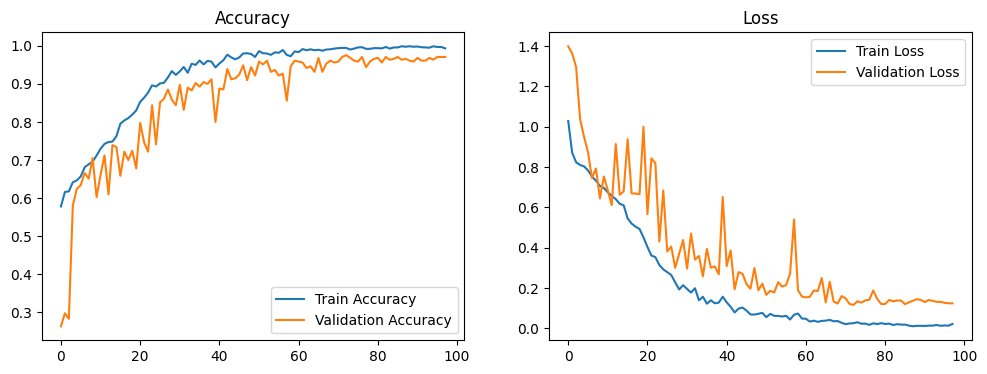


--- Evaluación Final en Test Set ---
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9756 - loss: 0.1168 
🏆 Test Accuracy: 97.56%


In [8]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Loss')
    plt.show()

plot_history(history)

print("\n--- Evaluación Final en Test Set ---")
loss, accuracy = model.evaluate(test_dataset)
print(f"🏆 Test Accuracy: {accuracy*100:.2f}%")


--- RESULTADOS ---
🎯 Accuracy Cruda (Ventana a Ventana): 97.56%
🚀 Accuracy Suavizada (Experiencia de Usuario): 50.98%


<Figure size 800x600 with 0 Axes>

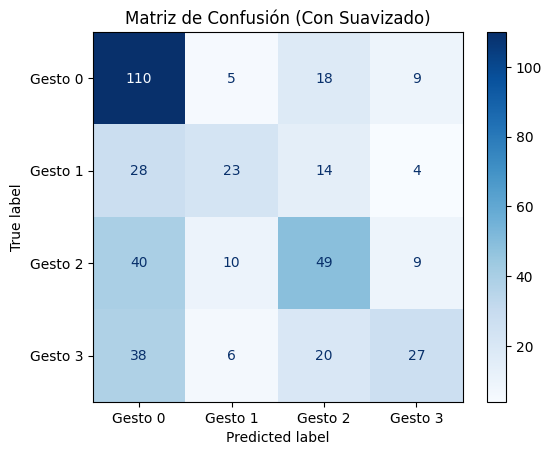


--- Reporte por Gesto ---
              precision    recall  f1-score   support

     Gesto 0       0.51      0.77      0.61       142
     Gesto 1       0.52      0.33      0.41        69
     Gesto 2       0.49      0.45      0.47       108
     Gesto 3       0.55      0.30      0.39        91

    accuracy                           0.51       410
   macro avg       0.52      0.46      0.47       410
weighted avg       0.51      0.51      0.49       410



In [9]:
acc_raw = accuracy_score(y_true_classes, y_pred_classes)
print(f"\n--- RESULTADOS ---")
print(f"🎯 Accuracy Cruda (Ventana a Ventana): {acc_raw*100:.2f}%")
print(f"🚀 Accuracy Suavizada (Experiencia de Usuario): {acc_smooth*100:.2f}%")

# Matriz de Confusión Estética con Matplotlib
class_names = [f'Gesto {i}' for i in range(4)]
cm = confusion_matrix(y_true_classes, y_pred_smoothed)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Matriz de Confusión (Con Suavizado)')
plt.show()

# Reporte detallado por Gesto
print("\n--- Reporte por Gesto ---")
print(classification_report(y_true_classes, y_pred_smoothed, target_names=class_names))